# Data Inspection for Drought Dataset

Using the drought data from the [U.S. Drought Monitor](https://droughtmonitor.unl.edu/CurrentMap.aspx).

Data downloaded has the following filters:


*   Date: 7/6/2006 - 7/6/2026
*   Area Type: County (by State)
*   Statistics Category: Percent Total
*   Statistics Type: Cumulative




In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import gdown

In [3]:
url = "https://drive.google.com/file/d/1CvbcnK4VLzAPwa_OzbbVve5O2VcxgjZT/view?usp=drive_link"
filepath = "dm_export_20060706_20260706"
gdown.download(url, filepath, fuzzy = True)

df = pd.read_csv(filepath)
df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1CvbcnK4VLzAPwa_OzbbVve5O2VcxgjZT
From (redirected): https://drive.google.com/uc?id=1CvbcnK4VLzAPwa_OzbbVve5O2VcxgjZT&confirm=t&uuid=ca346845-3549-4833-a7e7-75dccc90800b
To: /content/dm_export_20060706_20260706
100%|██████████| 306M/306M [00:02<00:00, 107MB/s]


,MapDate,FIPS,County,State,None,D0,D1,D2,D3,D4,ValidStart,ValidEnd,StatisticFormatID
0,20260630,2013,Aleutians East Borough,AK,100.0,0.0,0.0,0.0,0.0,0.0,2026-06-30,2026-07-06,1
1,20260623,2013,Aleutians East Borough,AK,100.0,0.0,0.0,0.0,0.0,0.0,2026-06-23,2026-06-29,1
2,20260616,2013,Aleutians East Borough,AK,100.0,0.0,0.0,0.0,0.0,0.0,2026-06-16,2026-06-22,1
3,20260609,2013,Aleutians East Borough,AK,100.0,0.0,0.0,0.0,0.0,0.0,2026-06-09,2026-06-15,1
4,20260602,2013,Aleutians East Borough,AK,100.0,0.0,0.0,0.0,0.0,0.0,2026-06-02,2026-06-08,1


In [4]:
#converting Valid Start and Valid End to Date Time
df["ValidStart"] = pd.to_datetime(df["ValidStart"])
df["ValidEnd"] = pd.to_datetime(df["ValidEnd"])
df.head()

,MapDate,FIPS,County,State,None,D0,D1,D2,D3,D4,ValidStart,ValidEnd,StatisticFormatID
0,20260630,2013,Aleutians East Borough,AK,100.0,0.0,0.0,0.0,0.0,0.0,2026-06-30,2026-07-06,1
1,20260623,2013,Aleutians East Borough,AK,100.0,0.0,0.0,0.0,0.0,0.0,2026-06-23,2026-06-29,1
2,20260616,2013,Aleutians East Borough,AK,100.0,0.0,0.0,0.0,0.0,0.0,2026-06-16,2026-06-22,1
3,20260609,2013,Aleutians East Borough,AK,100.0,0.0,0.0,0.0,0.0,0.0,2026-06-09,2026-06-15,1
4,20260602,2013,Aleutians East Borough,AK,100.0,0.0,0.0,0.0,0.0,0.0,2026-06-02,2026-06-08,1


## Looking at the structure of the data

In [5]:
df.describe()

,MapDate,FIPS,None,D0,D1,D2,D3,D4,ValidStart,ValidEnd,StatisticFormatID
count,3.363768e+06,3.363768e+06,3.363768e+06,3.363768e+06,3.363768e+06,3.363768e+06,3.363768e+06,3.363768e+06,3363768,3363768,3363768.0
mean,2.016067e+07,3.137789e+04,6.025320e+01,3.974680e+01,2.225428e+01,1.124163e+01,4.825751e+00,1.390421e+00,2016-07-01 11:59:59.999999744,2016-07-07 11:59:59.999999488,1.0
min,2.006070e+07,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2006-07-04 00:00:00,2006-07-10 00:00:00,1.0
25%,2.011069e+07,1.902900e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2011-07-03 06:00:00,2011-07-09 06:00:00,1.0
50%,2.016067e+07,3.002200e+04,1.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2016-07-01 12:00:00,2016-07-07 12:00:00,1.0
75%,2.021065e+07,4.610500e+04,1.000000e+02,1.000000e+02,1.977000e+01,0.000000e+00,0.000000e+00,0.000000e+00,2021-06-30 18:00:00,2021-07-06 18:00:00,1.0
max,2.026063e+07,7.215300e+04,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,2026-06-30 00:00:00,2026-07-06 00:00:00,1.0
std,5.786571e+04,1.629702e+04,4.668757e+01,4.668757e+01,3.957949e+01,2.985872e+01,1.999744e+01,1.075580e+01,NaN,NaN,0.0


In [29]:
df["FIPS"] = df["FIPS"].astype(str).str.zfill(5)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3363768 entries, 0 to 3363767
Data columns (total 14 columns):
 #   Column             Dtype         
---  ------             -----         
 0   MapDate            int64         
 1   FIPS               object        
 2   County             object        
 3   State              object        
 4   None               float64       
 5   D0                 float64       
 6   D1                 float64       
 7   D2                 float64       
 8   D3                 float64       
 9   D4                 float64       
 10  ValidStart         datetime64[ns]
 11  ValidEnd           datetime64[ns]
 12  StatisticFormatID  int64         
 13  Year               int32         
dtypes: datetime64[ns](2), float64(6), int32(1), int64(2), object(3)
memory usage: 346.5+ MB


In [7]:
df.isna().sum()

,0
MapDate,0
FIPS,0
County,0
State,0
None,0
D0,0
D1,0
D2,0
D3,0
D4,0


array([[<Axes: title={'center': 'MapDate'}>,
        <Axes: title={'center': 'FIPS'}>,
        <Axes: title={'center': 'None'}>],
       [<Axes: title={'center': 'D0'}>, <Axes: title={'center': 'D1'}>,
        <Axes: title={'center': 'D2'}>],
       [<Axes: title={'center': 'D3'}>, <Axes: title={'center': 'D4'}>,
        <Axes: title={'center': 'ValidStart'}>],
       [<Axes: title={'center': 'ValidEnd'}>,
        <Axes: title={'center': 'StatisticFormatID'}>, <Axes: >]],
      dtype=object)

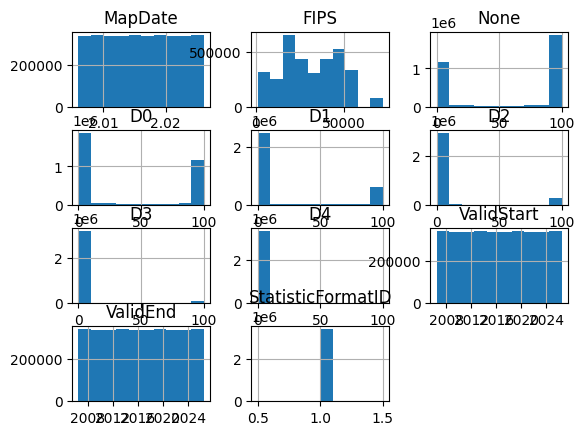

In [9]:
df.hist()

Below, we can see the data structure.

In [10]:
print("Rows:", len(df))
print("States:", df["State"].nunique())
print("Counties:", df["County"].nunique())

print("Earliest date:",df["ValidStart"].min())
print("Latest date:", df["ValidEnd"].max())

Rows: 3363768
States: 52
Counties: 1959
Earliest date: 2006-07-04 00:00:00
Latest date: 2026-07-06 00:00:00


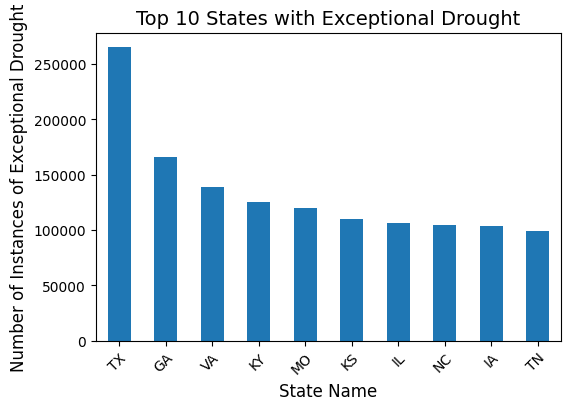

In [11]:
plt.figure(figsize = (6,4))
df['State'].value_counts().head(10).plot(kind = "bar")
plt.title("Top 10 States with Exceptional Drought", fontsize = 14)
plt.ylabel("Number of Instances of Exceptional Drought", fontsize = 12)
plt.xlabel("State Name", fontsize = 12)
plt.xticks(rotation = 45, rotation_mode = "anchor", ha = "right")
plt.show()

In [15]:
county = (
    df.groupby("County")["D4"]
      .mean()
      .sort_values(ascending=False)
)

county.head(20)

,D4
County,
Tulare County,19.211121
Fresno County,17.594262
Madera County,16.640211
Mariposa County,16.311044
Kern County,15.809914
Ventura County,15.321657
San Luis Obispo County,14.665172
Merced County,14.308228
Santa Barbara County,14.275086


Below we can see how common each of the drought categories are. D4 (highest severity of drought) occurs the least.

<Axes: >

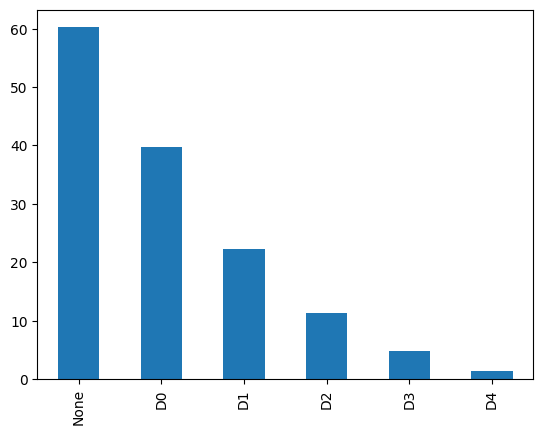

In [18]:
avg = df[["None","D0","D1","D2","D3","D4"]].mean()

avg.plot(kind="bar")

In [19]:
df[["None","D0","D1","D2","D3","D4"]].describe().map('{:.2f}'.format)

,None,D0,D1,D2,D3,D4
count,3363768.00,3363768.00,3363768.00,3363768.00,3363768.00,3363768.00
mean,60.25,39.75,22.25,11.24,4.83,1.39
std,46.69,46.69,39.58,29.86,20.00,10.76
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,100.00,0.00,0.00,0.00,0.00,0.00
75%,100.00,100.00,19.77,0.00,0.00,0.00
max,100.00,100.00,100.00,100.00,100.00,100.00


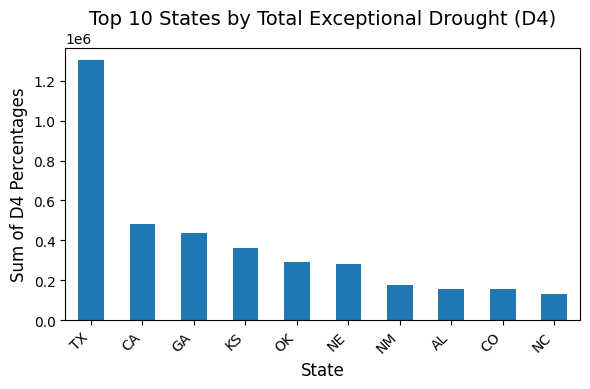

In [20]:
state_d4 = (
    df[df["D4"] > 0]
      .groupby("State")["D4"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(6,4))
state_d4.plot(kind="bar")

plt.title("Top 10 States by Total Exceptional Drought (D4)", fontsize=14)
plt.ylabel("Sum of D4 Percentages", fontsize=12)
plt.xlabel("State", fontsize=12)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Correlation Analysis

<Axes: >

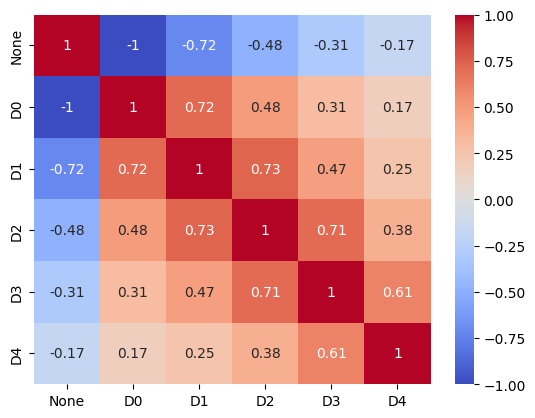

In [21]:
import seaborn as sns

corr = df[["None","D0","D1","D2","D3","D4"]].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

## Time Series Analysis
### Monthly Trend

<Axes: xlabel='ValidStart'>

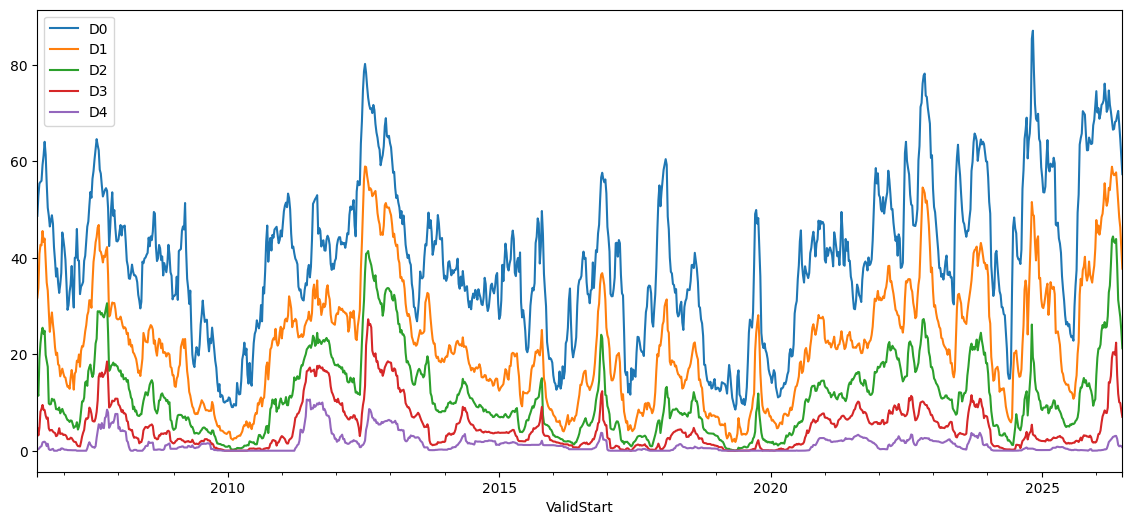

In [22]:
monthly = df.groupby("ValidStart")[["D0","D1","D2","D3","D4"]].mean()
monthly.plot(figsize=(14,6))

### Yearly Trend

In [23]:
import matplotlib.ticker as ticker

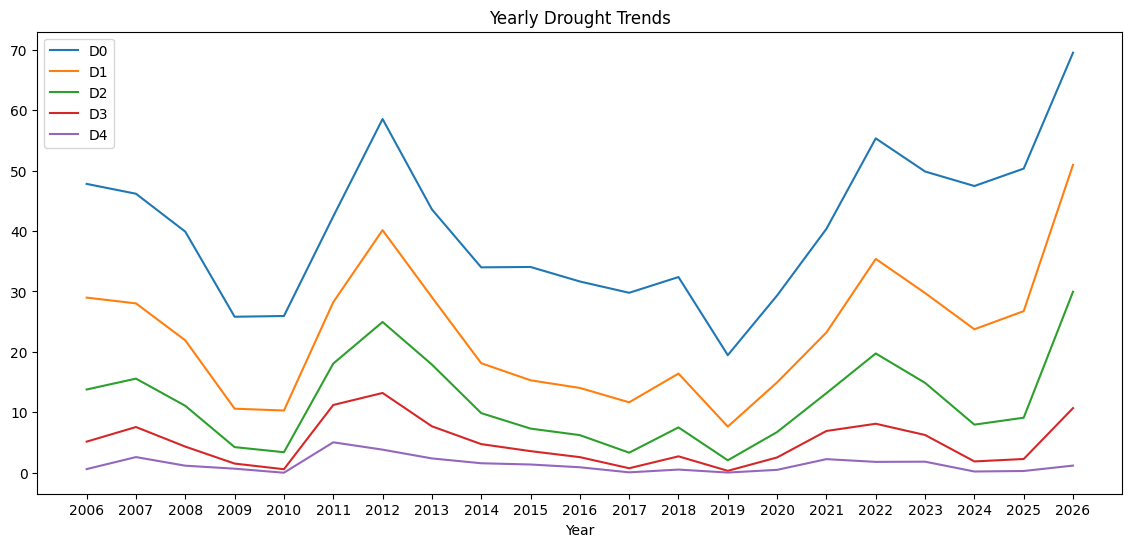

In [69]:
import matplotlib.pyplot as plt

yearly.plot(figsize=(14,6), title="Yearly Drought Trends")

plt.xticks(yearly.index)

plt.show()

What happened in 2012? https://www.weather.gov/iwx/2012_drought

## Heatmap
We want to be able to see where the different types of drought are occuring the most on a map.

In [33]:
import json
from urllib.request import urlopen

with urlopen(
    "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
) as response:
    counties = json.load(response)

In [79]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"

df_date = df[df["ValidStart"] == "2025-06-24"]

px.choropleth(
    df_date,
    geojson=counties,
    locations="FIPS",
    color="D4",
    scope="usa",
    title= "D4 - Exceptional Drought in 2025"

)

Output hidden; open in https://colab.research.google.com to view.

In [77]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"

df_date = df[df["ValidStart"] == "2020-06-30"]

px.choropleth(
    df_date,
    geojson=counties,
    locations="FIPS",
    color="D4",
    scope="usa",
    title= "D4 - Exceptional Drought in 2020"
)

Output hidden; open in https://colab.research.google.com to view.

In [76]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"

df_date = df[df["ValidStart"] == "2015-06-30"]

px.choropleth(
    df_date,
    geojson=counties,
    locations="FIPS",
    color="D4",
    scope="usa",
    title= "D4 - Exceptional Drought in 2015"

)

Output hidden; open in https://colab.research.google.com to view.

In [75]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"

df_date = df[df["ValidStart"] == "2010-06-29"]

px.choropleth(
    df_date,
    geojson=counties,
    locations="FIPS",
    color="D4",
    scope="usa",
    title= "D4 - Exceptional Drought in 2010"
)

Output hidden; open in https://colab.research.google.com to view.

## Mapping Change Over Time

In [43]:
df["Year"] = df["ValidStart"].dt.year
df["Year"].head()

,Year
0,2026
1,2026
2,2026
3,2026
4,2026


In [52]:
print(df["FIPS"].dtype)

object


In [59]:
for date in selected_dates:
  print(date)
  print(df_year

2000-06-27
(3222, 14)
2005-06-28
(3222, 14)
2010-06-29
(3222, 14)
2015-06-30
(3222, 14)
2020-06-30
(3222, 14)
2025-06-24
(3222, 14)


In [60]:
for year in [2000, 2005, 2010, 2015, 2020, 2025]:
    print(year)
    print(df[df["ValidStart"].dt.year == year]["ValidStart"].unique()[:5])

2000
<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]
2005
<DatetimeArray>
[]
Length: 0, dtype: datetime64[ns]
2010
<DatetimeArray>
['2010-12-28 00:00:00', '2010-12-21 00:00:00', '2010-12-14 00:00:00',
 '2010-12-07 00:00:00', '2010-11-30 00:00:00']
Length: 5, dtype: datetime64[ns]
2015
<DatetimeArray>
['2015-12-29 00:00:00', '2015-12-22 00:00:00', '2015-12-15 00:00:00',
 '2015-12-08 00:00:00', '2015-12-01 00:00:00']
Length: 5, dtype: datetime64[ns]
2020
<DatetimeArray>
['2020-12-29 00:00:00', '2020-12-22 00:00:00', '2020-12-15 00:00:00',
 '2020-12-08 00:00:00', '2020-12-01 00:00:00']
Length: 5, dtype: datetime64[ns]
2025
<DatetimeArray>
['2025-12-30 00:00:00', '2025-12-23 00:00:00', '2025-12-16 00:00:00',
 '2025-12-09 00:00:00', '2025-12-02 00:00:00']
Length: 5, dtype: datetime64[ns]
